In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
sns.set()

df = pd.read_csv("tmbd.csv")
print("Original Shape:", df.shape)

df.info
print(df.head(10))

Original Shape: (1287, 24)
   Unnamed: 0      id    imdb_id  popularity       budget       revenue  \
0           0  135397  tt0369610   32.985763  150000000.0  1.513529e+09   
1           1   76341  tt1392190   28.419936  150000000.0  3.784364e+08   
2           2  262500  tt2908446   13.112507  110000000.0  2.952382e+08   
3           3  140607  tt2488496   11.173104  200000000.0  2.068178e+09   
4           4  168259  tt2820852    9.335014  190000000.0  1.506249e+09   
5           5  281957  tt1663202    9.110700  135000000.0  5.329505e+08   
6           6   87101  tt1340138    8.654359  155000000.0  4.406035e+08   
7           7  286217  tt3659388    7.667400  108000000.0  5.953803e+08   
8           8  211672  tt2293640    7.404165   74000000.0  1.156731e+09   
9           9  150540  tt2096673    6.326804  175000000.0  8.537086e+08   

                 original_title  \
0                Jurassic World   
1            Mad Max: Fury Road   
2                     Insurgent   
3  Star

In [2]:
print(df.describe())
print("______________________________________________________________________________________________")
print(df.columns)

         Unnamed: 0             id   popularity        budget       revenue  \
count   1287.000000    1287.000000  1287.000000  1.287000e+03  1.287000e+03   
mean    4125.843046   52557.491064     1.786022  5.200349e+07  1.762444e+08   
std     2671.936574   74450.077163     2.172137  5.514540e+07  2.538156e+08   
min        0.000000      11.000000     0.010335  1.000000e+00  4.300000e+01   
25%     1972.000000    5851.500000     0.664783  1.400000e+07  2.565097e+07   
50%     3523.000000   20178.000000     1.152354  3.200000e+07  8.208716e+07   
75%     6554.500000   62209.500000     2.125342  7.000000e+07  2.140694e+08   
max    10760.000000  333348.000000    32.985763  4.250000e+08  2.781506e+09   

           runtime   vote_count  vote_average  release_year    budget_adj  \
count  1287.000000  1287.000000   1287.000000   1287.000000  1.287000e+03   
mean    110.273504   947.266511      6.279487   2007.017094  5.462994e+07   
std      18.811369  1255.476215      0.795955      8.0605

In [4]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)


initial_rows = df.shape[0]
df = df[(df['budget'] > 1000) & (df['revenue'] > 1000) & (df['runtime'] > 0)]
print("Rows removed:", initial_rows - df.shape[0])
df['release_date'] = pd.to_datetime(df['release_date'])
df.drop_duplicates(inplace=True)
print("Cleaned Shape:", df.shape)

Rows removed: 0
Cleaned Shape: (1280, 23)


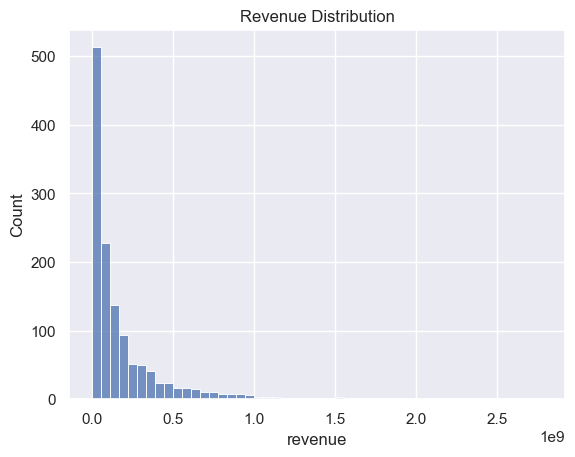

INSIGHT: Revenue is highly skewed — few blockbuster movies dominate earnings.


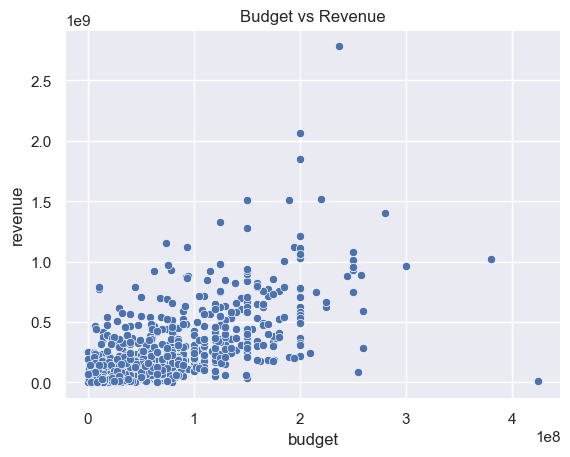

INSIGHT: Higher budget increases chances of success, but does not guarantee it.


In [14]:
#EDA- Exploratory data analysis 
#revenue

df['roi'] = df['revenue'] / df['budget']
df['profit_margin'] = df['profit'] / df['revenue']
df['release_month'] = df['release_date'].dt.month

plt.figure()
sns.histplot(df['revenue'], bins=50)
plt.title("Revenue Distribution")
plt.show()

print("INSIGHT: Revenue is highly skewed — few blockbuster movies dominate earnings.")

# Budget Vs Revenue
plt.figure()
sns.scatterplot(x='budget', y='revenue', data=df)
plt.title("Budget vs Revenue")
plt.show()

print("INSIGHT: Higher budget increases chances of success, but does not guarantee it.")


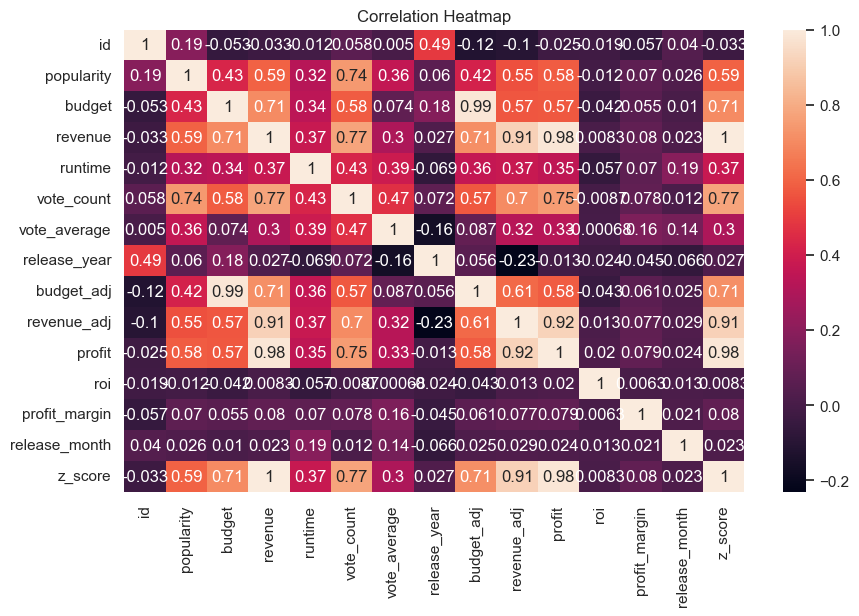

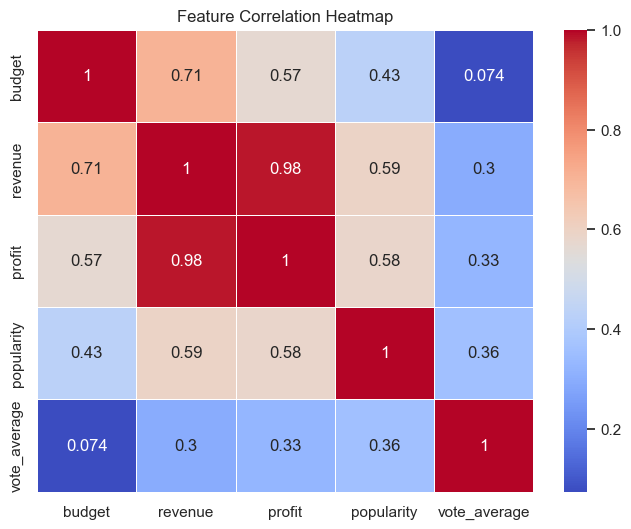

In [15]:
# here Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8,6))

corr = df[['budget', 'revenue', 'profit', 'popularity', 'vote_average']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

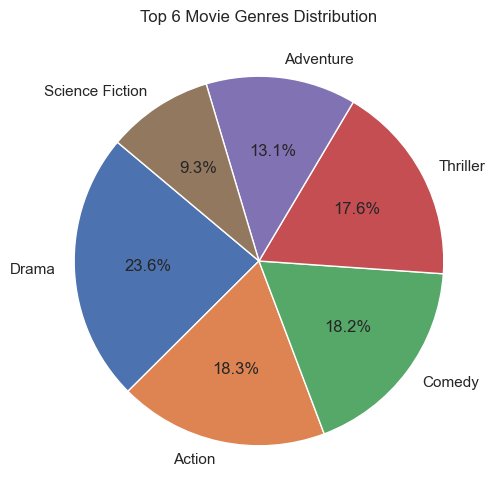

In [13]:
import matplotlib.pyplot as plt

# Prepare data
df['genres_split'] = df['genres'].str.split('|')
df_exploded = df.explode('genres_split')

genre_counts = df_exploded['genres_split'].value_counts().head(6)

plt.figure(figsize=(6,6))

plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Top 6 Movie Genres Distribution")
plt.show()

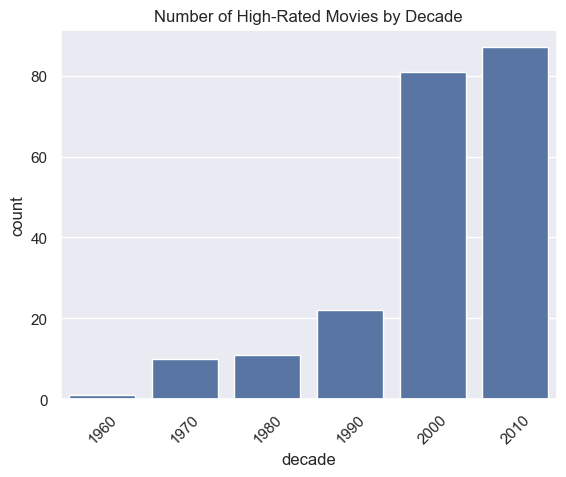

<Axes: xlabel='decade', ylabel='high_rated'>

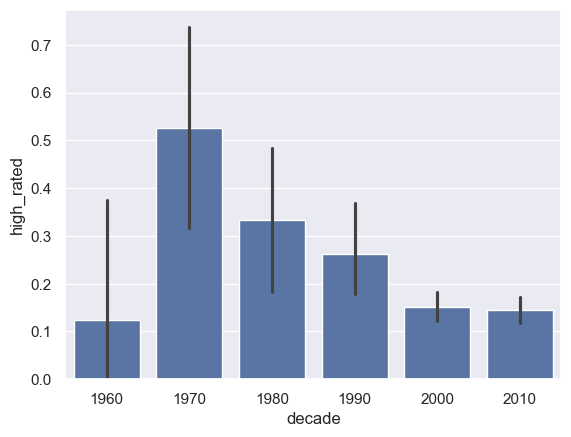

In [33]:
df['decade'] = (df['release_year'] // 10) * 10
high_rated = df[df['vote_average'] > 7]
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='decade', data=high_rated)
plt.title("Number of High-Rated Movies by Decade")
plt.xticks(rotation=45)
plt.show()

df['high_rated'] = df['vote_average'] > 7

sns.barplot(x='decade', y='high_rated', data=df)

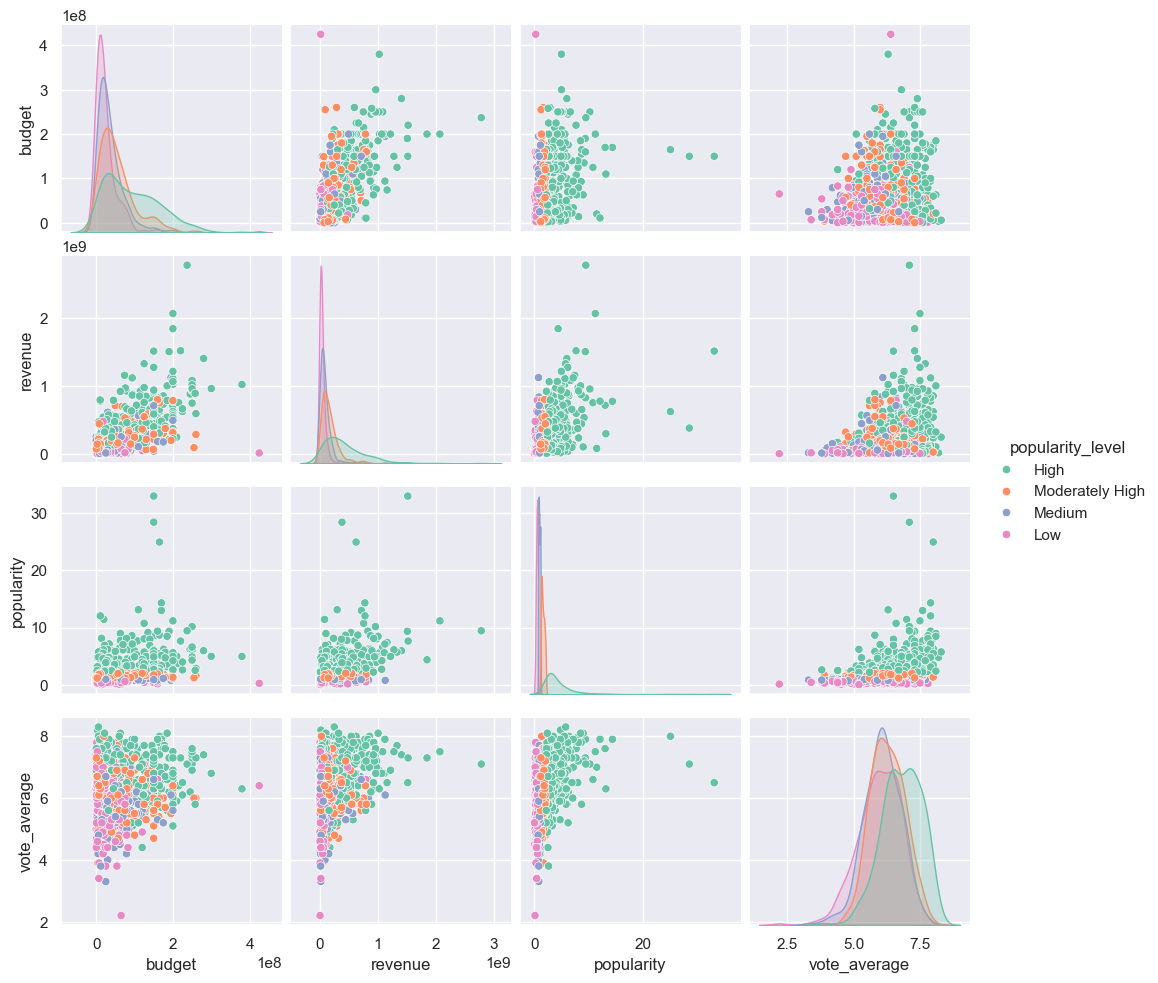

In [6]:
# sns.pairplot(
#     df[['budget', 'revenue', 'profit', 'popularity', 'vote_average']],
#     diag_kind='kde'
# )
sns.pairplot(
    df[['budget', 'revenue', 'popularity', 'vote_average', 'popularity_level']],
    hue='popularity_level',
    palette='Set2',
    diag_kind='kde'
)

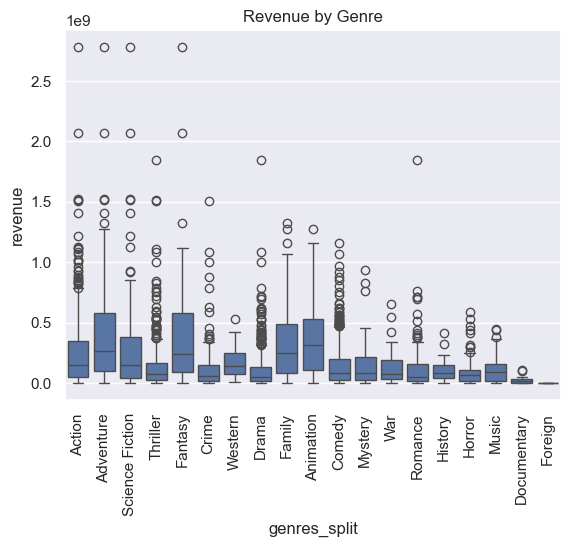

In [7]:
#genre analysis 
df['genres_split'] = df['genres'].str.split('|')
df_exploded = df.explode('genres_split')

plt.figure()
sns.boxplot(x='genres_split', y='revenue', data=df_exploded)
plt.xticks(rotation=90)
plt.title("Revenue by Genre")
plt.show()

In [8]:
top_movies = df.sort_values(by='revenue', ascending=False)[
    ['original_title', 'genres', 'revenue']
].head(10)

print(top_movies)

#showing outliers movies explicitly here 
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[df['revenue'] > Q3 + 1.5*IQR]

outliers[['original_title', 'revenue']].head(10)

                                   original_title  \
165                                        Avatar   
3                    Star Wars: The Force Awakens   
838                                       Titanic   
720                                  The Avengers   
0                                  Jurassic World   
4                                       Furious 7   
14                        Avengers: Age of Ultron   
536  Harry Potter and the Deathly Hallows: Part 2   
846                                        Frozen   
849                                    Iron Man 3   

                                        genres       revenue  
165   Action|Adventure|Fantasy|Science Fiction  2.781506e+09  
3     Action|Adventure|Science Fiction|Fantasy  2.068178e+09  
838                     Drama|Romance|Thriller  1.845034e+09  
720           Science Fiction|Action|Adventure  1.519558e+09  
0    Action|Adventure|Science Fiction|Thriller  1.513529e+09  
4                        Action|Crime|

,original_title,revenue
0,Jurassic World,1.513529e+09
3,Star Wars: The Force Awakens,2.068178e+09
4,Furious 7,1.506249e+09
5,The Revenant,5.329505e+08
7,The Martian,5.953803e+08
8,Minions,1.156731e+09
9,Inside Out,8.537086e+08
10,Spectre,8.806746e+08
14,Avengers: Age of Ultron,1.405036e+09
17,Ant-Man,5.186022e+08


In [9]:
#outlier detection
# IQR Method
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df[(df['revenue'] < Q1 - 1.5*IQR) | (df['revenue'] > Q3 + 1.5*IQR)]
print("IQR Outliers:", outliers_iqr.shape[0])

#ztest
df['z_score'] = stats.zscore(df['revenue'])
outliers_z = df[df['z_score'].abs() > 3]
print("Z-score Outliers:", outliers_z.shape[0])


IQR Outliers: 120
Z-score Outliers: 27


In [26]:
#machine learning model
# we train and test here basically used for prediction and stuff
features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count']
X = df[features]
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

score = model.score(X_test, y_test)
print("Model R^2 Score:", score)


print("INSIGHT: Model performance shows how predictable movie success is.")
print("If we have these input features, the model can estimate movie revenue and give a reasonable approximation of success, but it is not perfectly accurate.")


Model R^2 Score: 0.7195028132495123
INSIGHT: Model performance shows how predictable movie success is.
If we have these input features, the model can estimate movie revenue and give a reasonable approximation of success, but it is not perfectly accurate.


In [6]:

high = df[df['vote_average'] > 7]['revenue']
low = df[df['vote_average'] <= 7]['revenue']

t_stat, p_value = stats.ttest_ind(high, low)
print("T-test:", t_stat, p_value)

print("INSIGHT: Statistical test helps validate whether ratings impact revenue.")

T-test: 11.126702648696734 1.6302828200282783e-27
INSIGHT: Statistical test helps validate whether ratings impact revenue.


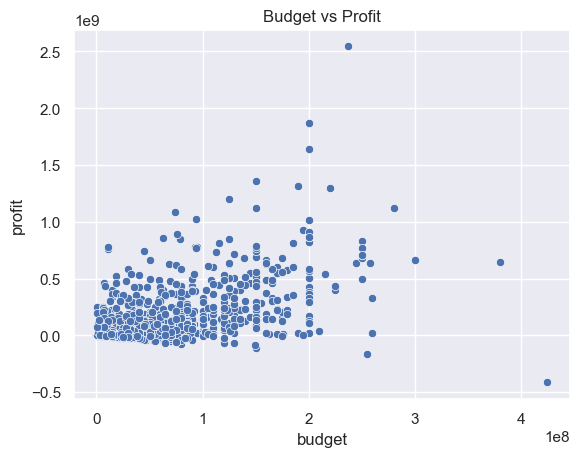

Conclusion for my objective:INSIGHT: Higher budget does not always lead to higher profit. But has moderate relation between them.
Correlation: 0.5681109018039291
P-value: 2.767378561223195e-110

Statistical Conclusion: Significant relationship exists between budget and profit.
Insight: Moderate relationship — higher budgets tend to increase profit, but not always.


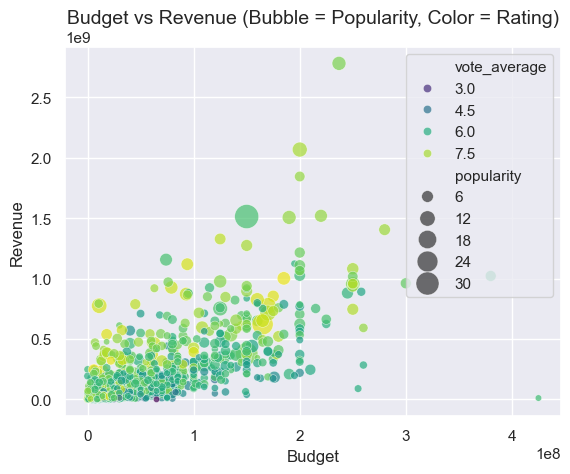

In [25]:
# Objective 1: does budget influence profit directly 

sns.scatterplot(x='budget', y='profit', data=df)
plt.title("Budget vs Profit")
plt.show()
print("Conclusion for my objective:INSIGHT: Higher budget does not always lead to higher profit. But has moderate relation between them.")
# This is my conclusion from scatterplot so next lets do statistical analysis to prove this

print("=====================================================================================================================================")
# Null Hypothesis: Budget and Profit are not related
# Alternate Hypothesis: Budget and profit are related 

from scipy.stats import pearsonr

corr, p_value = pearsonr(df['budget'], df['profit'])

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("\nStatistical Conclusion: Significant relationship exists between budget and profit.")
    
    if abs(corr) < 0.3:
        print("Insight: Weak relationship — budget has little impact on profit.")
    elif abs(corr) < 0.7:
        print("Insight: Moderate relationship — higher budgets tend to increase profit, but not always.")
    else:
        print("Insight: Strong relationship — budget strongly influences profit.")
else:
    print("\nStatistical Conclusion: No significant relationship between budget and profit.")

sns.scatterplot(x='budget',y='revenue',size='popularity',hue='vote_average',data=df,sizes=(20, 300),palette='viridis',alpha=0.7)
plt.title("Budget vs Revenue (Bubble = Popularity, Color = Rating)", fontsize=14)
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

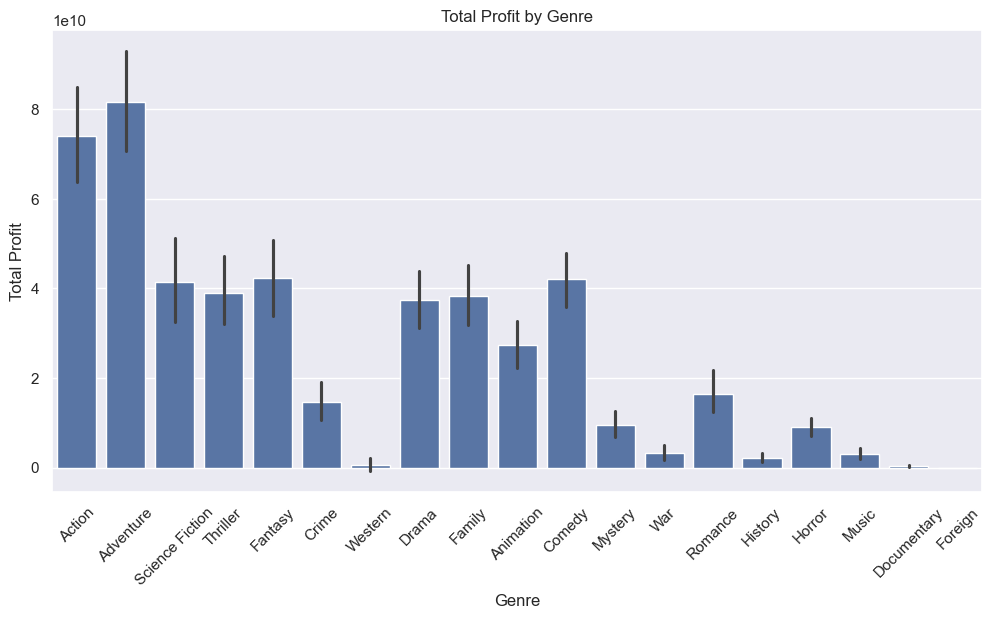

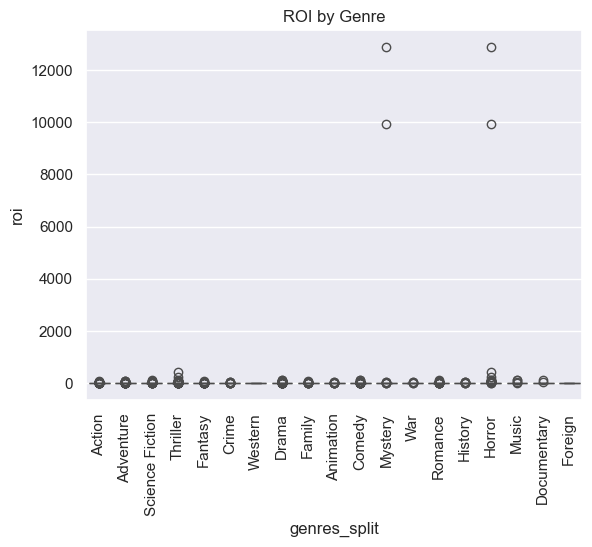

INSIGHT: ROI varies across genres, with some showing higher profitability and others showing more variability.
________________________________________________________________________________
                       mean    median  count
genres_split                                
Mystery          236.479346  2.438211     98
Horror           176.609571  2.777652    139
Documentary       12.757895  3.386987     15
Music              9.659478  2.606066     38
Thriller           6.425795  2.425286    396
Romance            5.339934  2.541222    194
Adventure          5.146331  2.907261    296
Science Fiction    5.050964  2.570823    209
Drama              4.903781  2.171429    531
Comedy             4.392888  2.454926    409
Family             4.363390  2.634837    163
Fantasy            4.156152  2.735933    154
History            4.092116  1.908741     35
Animation          3.941691  2.827579    108
War                3.918507  2.582198     32
Action             3.819551  2.484463    41

In [34]:
# Objective 2: Is ROI different across genres?
df['genres_split'] = df['genres'].str.split('|')
df_exploded = df.explode('genres_split')

# Visualization 
plt.figure(figsize=(12,6))
sns.barplot(x='genres_split', y='profit', data=df_exploded, estimator=sum)
plt.title("Total Profit by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Profit")
plt.show()

#Summary Statistics 
roi_summary = df_exploded.groupby('genres_split')['roi'].agg(['mean', 'median', 'count'])
print(roi_summary.sort_values(by='mean', ascending=False))
print("INSIGHT: Some genres have higher average ROI, while others show wider spread indicating higher risk.")
print("________________________________________________________________________________")

# i am doing t test for genre (top vs bottom)
top = df_exploded.groupby('genres_split')['roi'].mean().idxmax()
low = df_exploded.groupby('genres_split')['roi'].mean().idxmin()
g1 = df_exploded[df_exploded['genres_split'] == top]['roi']
g2 = df_exploded[df_exploded['genres_split'] == low]['roi']

from scipy import stats
t_stat, p_value = stats.ttest_ind(g1, g2)

print(top, "vs", low)
print("T-test:", t_stat, p_value)

if p_value < 0.05:
    print("Conclusion: ROI difference between top and bottom genres is statistically significant.")
else:
    print("Conclusion: ROI difference between top and bottom genres is not statistically significant.")
print("________________________________________________________________________________")

# Chi-Square Test
# Converting our ROI into categories
df_exploded['roi_category'] = pd.qcut( df_exploded['roi'], 3,labels=['Low', 'Medium', 'High'])

from scipy.stats import chi2_contingency
contingency = pd.crosstab(
    df_exploded['genres_split'], df_exploded['roi_category'])
chi2, p, _, _ = chi2_contingency(contingency)
print("Chi-square p-value:", p)
if p < 0.05:
    print("Conclusion: Genre and ROI category are related.")
else:
    print("Conclusion: No strong relationship between genre and ROI.")
print("____________________________________________________________")
print("FINAL INSIGHT: ROI varies across genres. While some differences are visible, statistical tests show that the relationship is not always strong, indicating variability in movie performance.")

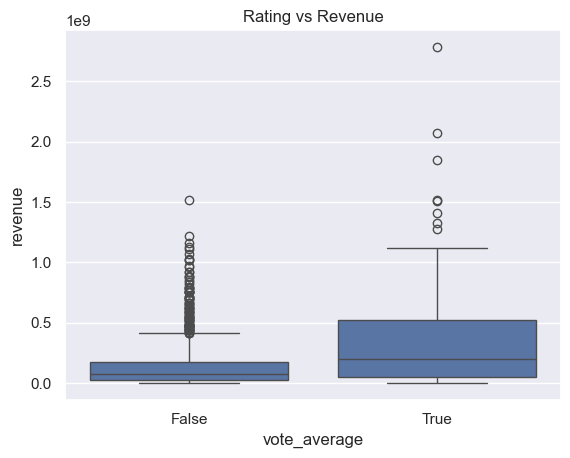

T-test: 11.126702648696734 1.6302828200282783e-27
Conclusion: Ratings influence revenue.


In [33]:
# Q3
sns.boxplot(x=df['vote_average'] > 7, y=df['revenue'])
plt.title("Rating vs Revenue")
plt.show()

high = df[df['vote_average'] > 7]['revenue']
low = df[df['vote_average'] <= 7]['revenue']

from scipy import stats
t_stat, p_value = stats.ttest_ind(high, low)

print("T-test:", t_stat, p_value)

if p_value < 0.05:
    print("Conclusion: Ratings influence revenue.")
else:
    print("Conclusion: Ratings do not significantly influence revenue.")

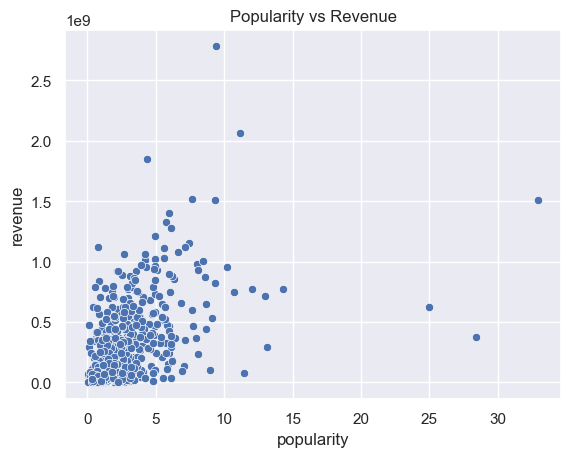

Q4 INSIGHT: Popularity is a strong indicator of revenue.


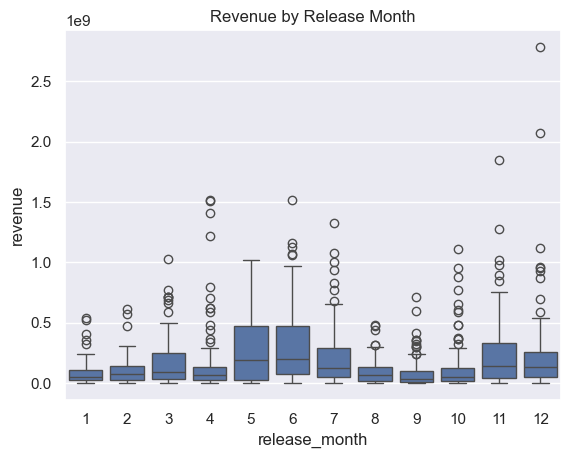

Q5 INSIGHT: Certain months show higher success trends.
There are lot of movies in 2026 too. As a Movie enthusiast many high budget movies are being released this December aand we can easily say what is the driving factor here


In [11]:
# 04 showing popularity vs revenue using seaborn with pairplot
#and which month brings great money for movie released through small visualization using boxplot 
sns.scatterplot(x='popularity', y='revenue', data=df)
plt.title("Popularity vs Revenue")
plt.show()
print("Q4 INSIGHT: Popularity is a strong indicator of revenue.")
 
sns.boxplot(x='release_month', y='revenue', data=df)
plt.title("Revenue by Release Month")
plt.show()
print(" INSIGHT: Certain months show higher success trends.")
print("There are lot of movies in 2026 too. As a Movie enthusiast many high budget movies are being released this December aand we can easily say what is the driving factor here")

In [35]:
#Objective 5: we will see if a movie will be success or not ?? we are making categories on that basis
df['success'] = df['revenue'] > df['revenue'].median()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

features = ['budget', 'popularity', 'runtime', 'vote_average', 'vote_count']
X = df[features]
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Prediction (1=Success, 0=Not):", prediction[0])
sample = X_test.iloc[0:1]
prediction = model.predict(sample)
print("Prediction (1=Success, 0=Not):", prediction[0])

Accuracy: 0.8203125
Prediction (1=Success, 0=Not): False
Prediction (1=Success, 0=Not): False
